/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_9528/3789742074.py:72: RuntimeWarning: Mean of empty slice
  i1_per_time = np.nanmean(i1_per_time, axis=-1)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


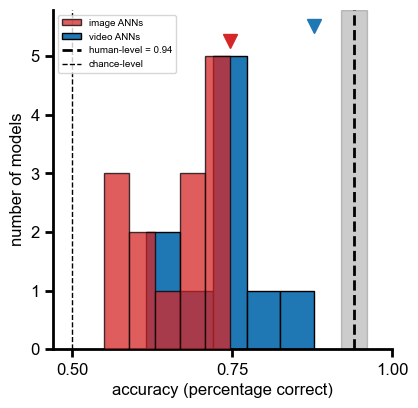

image ANNs mean accuracy: 0.66 ± 0.07
video ANNs mean accuracy: 0.72 ± 0.07
image ANNs - video ANNs mean difference: -0.06
image ANNs max accuracy: 0.75
video ANNs max accuracy: 0.88
t-test between image and video ANNs: TtestResult(statistic=np.float64(-2.163242680617722), pvalue=np.float64(0.04165659032808808), df=np.float64(22.0))


In [5]:
"""
Behavioral Decoding Analysis of Object Category for ANN models

This script visualizes histograms of models based on their behavioral performance. It processes pre-computed accuracy scores.

The analysis includes:
1. Loading accuracy scores from HDF5 file
2. Computing the highest accuracy across time bins for each model
3. Generating a histogram comparing static (image-based) vs dynamic (video-based) ANN models, with vertical lines indicating mean performance for each group and chance-level performance.

Key outputs:
- decode_obj_cat_linear_model_histogram.pdf: Histogram comparing model performance on object category decoding task, with mean performance indicated for static vs dynamic models.
"""

import sys
sys.path.append('../')

from utils.plot_utils import journal_figure_pdf, journal_figure

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy

import scienceplots

plt.style.use(['nature'])

static_models = {
    "images_moving2_alexnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'AlexNet'], 
    "images_moving2_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
    "images_moving2_densenet121_features_srp_1000_10.h5" : ['f', 'tab:red', 'DenseNet-121'], 
    "images_moving2_efficientnet_b0_features_srp_1000_10.h5" : ['f', 'tab:red', 'EfficientNet-B0'], 
    "images_moving2_hiera_features_srp_1000_10.h5" : ['f', 'tab:red', 'Hiera'], 
    "images_moving2_inception_v3_features_srp_1000_10.h5" : ['f', 'tab:red', 'Inception-V3'], 
    "images_moving2_pnasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'PNASNet'], 
    "images_moving2_resnet50_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50'], 
    "images_moving2_resnet50_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50-SSL'], 
    "images_moving2_vit_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT'], 
    "images_moving2_vit_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT-SSL'], 
    "images_moving2_nasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'NASNet'], 
    "images_moving2_rgc_intermediate_features_ff_srp_1000_10.h5" : ['ri', 'tab:red', 'ConvRNN-F'],
    "images_moving2_CORnet-S_IT_features_srp_1000_10.h5" : ['ri', 'tab:red', 'CORnet-S'],
}

dynamic_models = {
    "images_moving2_c2d_r50-blocks.4.res_blocks.5.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving2_i3d_r50-blocks.5.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving2_x3d_xs-blocks.4.res_blocks.6.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving2_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving2_slow_r50-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving2_timesformer_ssv2-timesformer.encoder.layer.8_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving2_timesformer-timesformer.encoder.layer.11_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving2_videomamba_ssv2-layers.10.mixer_features_srp_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving2_videomamba-layers.10.mixer_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving2_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
}

models = {**static_models, **dynamic_models}

scores_path = '../../scores/figure1'

values = []
errors = []
time_bins = []
methods_names = list(models.keys())
for name in methods_names:
    file_rgb = h5py.File(f'{scores_path}/{name}/decode_ann_obj_cat_linear.h5', 'r')
    i1_per_time = np.array(file_rgb[f'i1_all'])

    i1_per_time = np.nanmean(i1_per_time, axis=-1)
    i1_per_time = np.nanmean(i1_per_time, axis=0)

    i1_per_time_m = np.nanmean(i1_per_time, axis=-1)
    max_id = np.argmax(i1_per_time_m)
    i1_per_time = i1_per_time[max_id]

    i1_per_time_mean = np.nanmean(i1_per_time, axis=0)
    i1_per_time_se = np.nanstd(i1_per_time, axis=0) / np.sqrt(i1_per_time.shape[0])

    values.append(i1_per_time_mean)
    errors.append(i1_per_time_se)
    time_bins.append(max_id)


values_ff = np.array(values[:len(static_models)])
values_dd = np.array(values[len(static_models):])


plt.figure(figsize=(4, 5))
plt.hist(values_ff, bins=5, color='tab:red', alpha=.75, label='image ANNs', edgecolor='black', zorder=3)
plt.hist(values_dd, bins=5, color='tab:blue', label='video ANNs', edgecolor='black', zorder=1)

plt.plot(np.nanmax(values_ff), plt.ylim()[1] * 1.0, marker='v', color='tab:red', markersize=10, zorder=3)

plt.plot(np.nanmax(values_dd), plt.ylim()[1] * 1.0, marker='v', color='tab:blue', markersize=10, zorder=3)

human_c = 0.94 
human_err = 0.02 
plt.axvline(human_c, color='black', linestyle='--', linewidth=2, label=f'human-level = {np.round(human_c, 2)}')
plt.axvspan(human_c - human_err, human_c + human_err, color='black', alpha=0.2, zorder=3)


plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label=f'chance-level')

plt.xlabel('accuracy (percentage correct)', fontsize=12)
plt.ylabel('number of models', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.xlim(0.47, 1.0)
plt.xticks(np.arange(0.5, 1.01, 0.25), fontsize=6)

journal_figure(do_save=True, filename=f'../../plots/figure1_decode_obj_cat_linear_model_histogram.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure1_decode_obj_cat_linear_model_histogram.pdf')

plt.show()

print(f'image ANNs mean accuracy: {np.nanmean(values_ff):.2f} ± {np.nanstd(values_ff):.2f}')
print(f'video ANNs mean accuracy: {np.nanmean(values_dd):.2f} ± {np.nanstd(values_dd):.2f}')
print(f'image ANNs - video ANNs mean difference: {np.nanmean(values_ff) - np.nanmean(values_dd):.2f}')
print(f'image ANNs max accuracy: {np.nanmax(values_ff):.2f}')
print(f'video ANNs max accuracy: {np.nanmax(values_dd):.2f}')
print(f't-test between image and video ANNs: {scipy.stats.ttest_ind(values_ff, values_dd)}')

/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_9528/3757603058.py:50: RuntimeWarning: Mean of empty slice
  i1_per_time_cat_ = np.nanmean(i1_per_time_cat, axis=-1)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


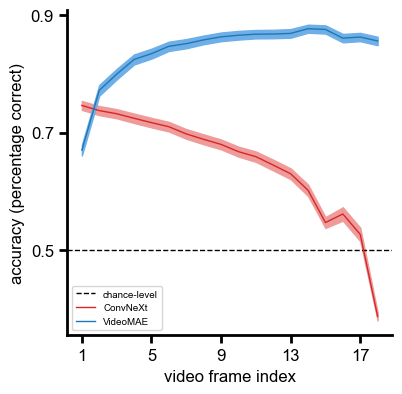

In [6]:
"""
Behavioral Decoding Analysis of Object Category for ANN models

This script visualizes histograms of models based on their behavioral performance. It processes pre-computed accuracy scores.

The analysis includes:
1. Loading accuracy scores from HDF5 file
2. Computing the highest accuracy across time bins for each model
3. Generating a histogram comparing static (image-based) vs dynamic (video-based) ANN models, with vertical lines indicating mean performance for each group and chance-level performance.

Key outputs:
- decode_obj_cat_linear_model_histogram.pdf: Histogram comparing model performance on object category decoding task, with mean performance indicated for static vs dynamic models.
"""

import sys
sys.path.append('../')

from utils.plot_utils import journal_figure_pdf, journal_figure

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import scienceplots

plt.style.use(['nature'])

static_models = {
    "images_moving2_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
}

dynamic_models = {
    "images_moving2_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
}

models = {**static_models, **dynamic_models}

scores_path = '../../scores/figure1'

values_cat = []
errors_cat = []


methods_names = list(models.keys())
for name in methods_names:
    file_rgb_cat = h5py.File(f'{scores_path}/{name}/decode_ann_obj_cat_linear.h5', 'r')
    i1_per_time_cat = np.array(file_rgb_cat[f'i1_all'])

    i1_per_time_cat_ = np.nanmean(i1_per_time_cat, axis=-1)
    i1_per_time_cat_ = np.nanmean(i1_per_time_cat_, axis=0)
    i1_per_time_cat = np.nanmean(i1_per_time_cat_, axis=-1)

    values_cat.append(i1_per_time_cat)
    errors_cat.append(np.nanstd(i1_per_time_cat_, axis=-1) / np.sqrt(i1_per_time_cat_.shape[-1]))
    #print(name, 'cat', np.nanmean(i1_per_time_cat))

    


values_cat_ff = np.array(values_cat[:len(static_models)])
errors_cat_ff = np.array(errors_cat[:len(static_models)])

values_cat_dd = np.array(values_cat[len(static_models):])
errors_cat_dd = np.array(errors_cat[len(static_models):])

plt.figure(figsize=(4, 5))

plt.errorbar(range(values_cat_ff.shape[1]), np.nanmean(values_cat_ff, 0), 
            #yerr=np.nanmean(errors_cat_ff, 0),
            c='tab:red',
            #capsize=5, 
            #marker='o',
            linestyle='-',
            label=f'ConvNeXt'
            )
plt.fill_between(range(values_cat_ff.shape[1]), 
                 np.nanmean(values_cat_ff, 0) - np.nanmean(errors_cat_ff, 0), 
                 np.nanmean(values_cat_ff, 0) + np.nanmean(errors_cat_ff, 0), 
                 color="#ee9b9a")  

plt.errorbar(range(values_cat_dd.shape[1]), np.nanmean(values_cat_dd, 0), 
            #yerr=np.nanmean(errors_cat_dd, 0),
            c='tab:blue',
            #capsize=5, 
            #marker='o',
            linestyle='-',
            label=f'VideoMAE'
            )
plt.fill_between(range(values_cat_dd.shape[1]), 
                 np.nanmean(values_cat_dd, 0) - np.nanmean(errors_cat_dd, 0), 
                 np.nanmean(values_cat_dd, 0) + np.nanmean(errors_cat_dd, 0), 
                 color="#6eafe8")  

plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label=f'chance-level')

plt.xlabel('video frame index', fontsize=12)
plt.ylabel('accuracy (percentage correct)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
#plt.ylim(0.47, 1.0)
plt.yticks(np.arange(0.5, 0.91, 0.2), fontsize=6)
plt.xticks(np.arange(0, 18, 4), np.arange(1, 19, 4), fontsize=6)

journal_figure(do_save=True, filename=f'../../plots/figure1_decode_obj_cat_linear_model_time_resolved.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure1_decode_obj_cat_linear_model_time_resolved.pdf')

plt.show()